<a href="https://colab.research.google.com/github/Ekinuc/42_Philosophers/blob/master/audioai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip /content/drive/MyDrive/AI/Odyogram_classification_dataset.zip -d /content/drive/MyDrive/AI

Archive:  /content/drive/MyDrive/AI/Odyogram_classification_dataset.zip
   creating: /content/drive/MyDrive/AI/Odyogram_classification_dataset/
  inflating: /content/drive/MyDrive/AI/__MACOSX/._Odyogram_classification_dataset  
   creating: /content/drive/MyDrive/AI/Odyogram_classification_dataset/train/
  inflating: /content/drive/MyDrive/AI/__MACOSX/Odyogram_classification_dataset/._train  
   creating: /content/drive/MyDrive/AI/Odyogram_classification_dataset/val/
  inflating: /content/drive/MyDrive/AI/__MACOSX/Odyogram_classification_dataset/._val  
   creating: /content/drive/MyDrive/AI/Odyogram_classification_dataset/train/Tinnitus/
  inflating: /content/drive/MyDrive/AI/__MACOSX/Odyogram_classification_dataset/train/._Tinnitus  
   creating: /content/drive/MyDrive/AI/Odyogram_classification_dataset/train/Normal/
  inflating: /content/drive/MyDrive/AI/__MACOSX/Odyogram_classification_dataset/train/._Normal  
   creating: /content/drive/MyDrive/AI/Odyogram_classification_dataset/v

In [ ]:
import sys
!{sys.executable} -m pip install tensorflow

In [ ]:
import os
import zipfile
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# --- 1. EXTRACTING THE DATASET (I/O OPTIMIZATION) ---
# We extract the zip to Colab's local disk for faster training speeds
#ZIP_PATH = '/content/drive/MyDrive/AI/Odyogram_classification_dataset.zip'
LOCAL_EXTRACT_DIR = '/content/drive/MyDrive/AI/Odyogram_classification_dataset'


# --- 2. SETUP PATHS & HYPERPARAMETERS ---
# NOTE: If your zip contains a root folder, you might need to adjust these paths
# (e.g., os.path.join(LOCAL_EXTRACT_DIR, 'Odyogram_Siniflandirma_Veriseti', 'train'))
TRAIN_DIR = os.path.join(LOCAL_EXTRACT_DIR, 'train')
VAL_DIR = os.path.join(LOCAL_EXTRACT_DIR, 'val')

IMG_SIZE = (224, 224) # Standard input size for MobileNetV2
BATCH_SIZE = 16
EPOCHS = 30

print("\n🚀 Initializing data loaders...")

# --- 3. DATA AUGMENTATION & GENERATORS ---
# Creating slight variations to prevent the model from memorizing the images (Overfitting)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to [0, 1]
    rotation_range=5,         # Slight rotation
    width_shift_range=0.05,   # Slight horizontal shift
    height_shift_range=0.05,  # Slight vertical shift
    zoom_range=0.05,          # Slight zoom
    fill_mode='nearest'
)

# We NEVER augment validation data. We only scale it.
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- 4. YAPAY ZEKA MİMARİSİ (GERÇEK FINE-TUNING) ---
print("\n🧠 MobileNetV2'nin kilitleri açılıyor (Fine-Tuning)...")

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# KİLİDİ AÇIYORUZ! Artık MobileNet'in kendisi de eğitilecek
base_model.trainable = True

# Ancak modelin en altındaki temel çizgi/kenar bulma yeteneklerini bozmamak için,
# Sadece en üstteki (son karar) 20 katmanı eğitime açık bırakıyoruz.
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Kendi teşhis katmanlarımızı ekliyoruz
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x) # Unutma oranını tekrar dengeli %50'ye çektik
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    # Çok kritik: Kilidi açtığımız için öğrenme hızını İYİCE düşürmeliyiz ki
    # modelin bildiklerini şiddetli bir şekilde bozmayalım. (1e-5)
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5. CALLBACKS (CHECKPOINT & EARLY STOPPING) ---
# Safely store the best model directly to your Google Drive
DRIVE_SAVE_PATH = '/content/drive/MyDrive/AI/best_audiogram_model.keras'

checkpoint = ModelCheckpoint(
    filepath=DRIVE_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=7, # Stop training if val_accuracy doesn't improve for 7 epochs
    restore_best_weights=True
)

# --- 6. START TRAINING ---
print(f"\n🔥 Training started! Best model will be safely saved to: {DRIVE_SAVE_PATH}\n")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop]
)

print(f"\n🎉 Training finished! You can find your golden model at: {DRIVE_SAVE_PATH}")


🚀 Initializing data loaders...
Found 814 images belonging to 2 classes.
Found 204 images belonging to 2 classes.

🧠 MobileNetV2'nin kilitleri açılıyor (Fine-Tuning)...

🔥 Training started! Best model will be safely saved to: /content/drive/MyDrive/AI/best_audiogram_model.keras

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.5792 - loss: 0.7305
Epoch 1: val_accuracy improved from None to 0.39706, saving model to /content/drive/MyDrive/AI/best_audiogram_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI/best_audiogram_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 47s 630ms/step - accuracy: 0.6388 - loss: 0.6637 - val_accuracy: 0.3971 - val_loss: 0.7326
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7205 - loss: 0.5439
Epoch 2: val_accuracy improved from 0.39706 to 0.59314, saving model to /content/drive/MyDrive/AI/best_audiogram_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI/best_audiogram_model.keras
51/51 ━

🧠 Model yükleniyor...
✅ Model başarıyla yüklendi!

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
----------------------------------------
🎯 YAPAY ZEKA TEŞHİS RAPORU
----------------------------------------
Normal İşitme Olasılığı : %36.28
Tinnitus (Çınlama) Olasılığı: %63.72
----------------------------------------
🚨 YAPAY ZEKA KARARI: Hastada TİNNİTUS (Çınlama / Kayıp) tespit edildi!


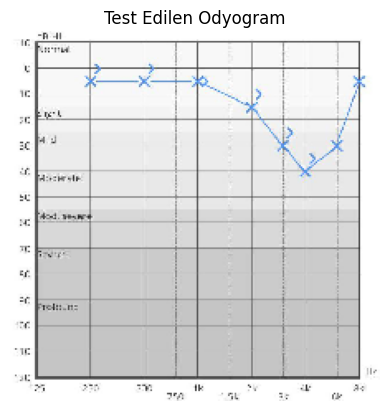

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Eğittiğimiz O Altın Modeli Yükleyelim
MODEL_YOLU = '/content/drive/MyDrive/AI/best_audiogram_model.keras'
print("🧠 Model yükleniyor...")
model = tf.keras.models.load_model(MODEL_YOLU)
print("✅ Model başarıyla yüklendi!\n")

# 2. Test Etmek İstediğin Resmin Yolunu Buraya Yaz
# (Drive'ından veya sol menüden rastgele bir T veya N resmi seçip yolunu kopyala)
TEST_RESMI_YOLU = '/content/drive/MyDrive/AI/Odyogram_classification_dataset/val/Tinnitus/T139 Left.jpg' # BURAYI KENDİNE GÖRE DEĞİŞTİR

def odyogrami_test_et(resim_yolu):
    # Resmi modelin anlayacağı formata (224x224 ve 0-1 arası) getiriyoruz
    img = image.load_img(resim_yolu, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Batch boyutuna genişlet
    img_array = img_array / 255.0 # Eğitimdeki gibi normalize et (Standardizasyon)

    # Yapay Zeka Tahmin Yapıyor!
    tahminler = model.predict(img_array)

    # flow_from_directory klasörleri alfabetik sıralar: Normal (0), Tinnitus (1)
    normal_ihtimali = tahminler[0][0] * 100
    tinnitus_ihtimali = tahminler[0][1] * 100

    # Sonucu ekrana şık bir şekilde yazdır
    print("-" * 40)
    print("🎯 YAPAY ZEKA TEŞHİS RAPORU")
    print("-" * 40)
    print(f"Normal İşitme Olasılığı : %{normal_ihtimali:.2f}")
    print(f"Tinnitus (Çınlama) Olasılığı: %{tinnitus_ihtimali:.2f}")
    print("-" * 40)

    if tinnitus_ihtimali > normal_ihtimali:
        print("🚨 YAPAY ZEKA KARARI: Hastada TİNNİTUS (Çınlama / Kayıp) tespit edildi!")
    else:
        print("✅ YAPAY ZEKA KARARI: Hastanın işitmesi NORMAL.")


    plt.imshow(img)
    plt.axis('off')
    plt.title("Test Edilen Odyogram")
    plt.show()

# Testi Başlat
try:
    odyogrami_test_et(TEST_RESMI_YOLU)
except FileNotFoundError:
    print("❌ HATA: Resim bulunamadı. Lütfen TEST_RESMI_YOLU değişkenindeki dosya yolunu doğru yazdığınızdan emin olun.")